using previously downloaded sample video: 'sample_demo_video.mp4'
processing video
done.processed 62 frames in 10.0s
total unique visitors: 46
average dwell time: 1.6s | max dwell time: 2.0s
saved: annoted_output.mp4, movement_heatmap.png


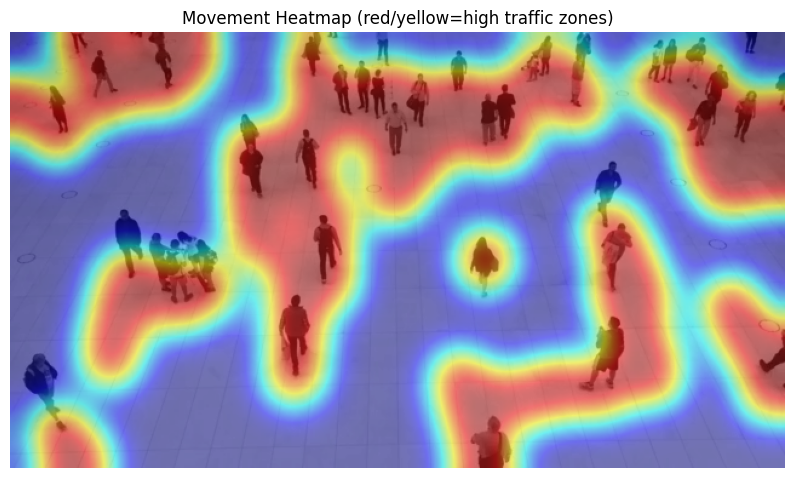

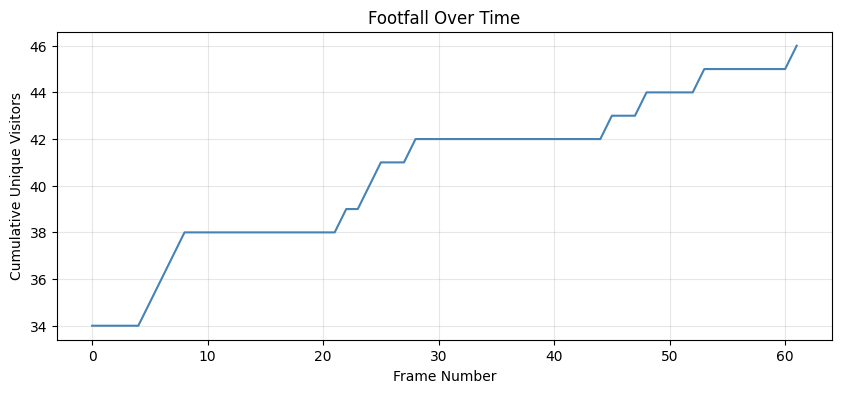

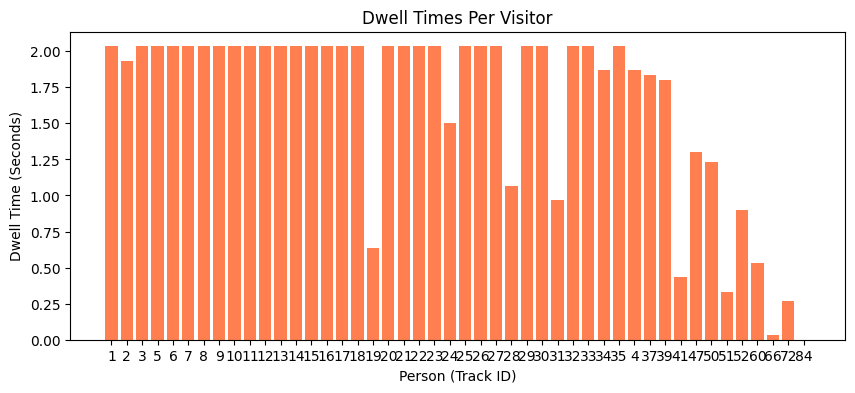

In [8]:
import argparse
import os
import time
import urllib.request
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO # Corrected: yolo -> YOLO

person_class_id=0
sample_video_url="https://github.com/ultralytics/assets/releases/download/v0.0.0/solutions_ci_demo.mp4" # Corrected: assests -> assets and added /releases
sample_video_name="sample_demo_video.mp4"

def get_sample_video(dest:str=sample_video_name)->str:
  if not os.path.exists(dest):
    print(f"no video provided - downloading a sample demo clip to '{dest}'")
    urllib.request.urlretrieve(sample_video_url,dest)
    print("sample video downloaded")
  else: # Fix: added colon and corrected indentation
    print(f"using previously downloaded sample video: '{dest}'") # Minor fix: downloade -> downloaded
  return dest

def run_pipline(video_path:str,model_name:str="yolov8n.pt", # Fix: yo1ov8n.pt -> yolov8n.pt
                output_video:str="annoted_output.mp4",
                heatmap_path:str="movement_heatmap.png",
                show_plots:bool=True):
  model=YOLO(model_name) # Fix: yolo -> YOLO, and proper indentation
  cap=cv2.VideoCapture(video_path) # Fix: cv2.videocapture -> cv2.VideoCapture

  if not cap.isOpened(): # Fix: isopened -> isOpened
    raise FileNotFoundError(f"Could not open video: {video_path}") # Fix: filenotfounderror -> FileNotFoundError, minor casing

  fps = cap.get(cv2.CAP_PROP_FPS) or 25 # Fix: cv2.cap_peop_fps -> cv2.CAP_PROP_FPS, and assigned to fps
  width=int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)) # Fix: cv2.cap_prop_frame_width -> cv2.CAP_PROP_FRAME_WIDTH
  height=int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)) # Fix: cv2.cap_prop_frame_height -> cv2.CAP_PROP_FRAME_HEIGHT
  writer=cv2.VideoWriter(output_video,cv2.VideoWriter_fourcc(*"mp4v"),fps,(width,height)) # Fix: cv2.videowriter -> cv2.VideoWriter, cv2.videowriter_fourcc -> cv2.VideoWriter_fourcc
  heatmap_acc=np.zeros((height,width),dtype=np.float32) # Fix: np.zeroes -> np.zeros, consistent with heatmap_acc

  track_first_seen,track_last_seen={},{}
  footfall_over_time=[]
  seen_ids=set()
  ref_frame=None
  frame_num=0
  print("processing video")
  start_time=time.time()

  while cap.isOpened(): # Fix: isopened -> isOpened
    ret,frame=cap.read()
    if not ret:
      break

    if ref_frame is None: # Corrected indentation
      ref_frame=frame.copy()

    results=model.track(
                        frame,persist=True,classes=[person_class_id],
                        tracker="bytetrack.yaml",verbose=False
    )
    if results[0].boxes.id is not None:
      boxes=results[0].boxes.xyxy.cpu().numpy()
      track_ids=results[0].boxes.id.cpu().numpy().astype(int)
      for box,track_id in zip(boxes,track_ids):
        x1,y1,x2,y2=box
        cx,cy=int((x1+x2)/2),int(y2) # Fix: int((x1+x2)/2,int(y2)) -> int((x1+x2)/2), int(y2)
        if 0<=cy<height and 0<=cx<width:
          cv2.circle(heatmap_acc,(cx,cy),25,1,-1)
          if track_id not in track_first_seen:
            track_first_seen[track_id]=frame_num
          track_last_seen[track_id]=frame_num # This should be updated in every frame the ID is seen
          seen_ids.add(track_id) # This should only be added once per track_id, but placing it here doesn't hurt as `add` handles duplicates
          cv2.rectangle(frame,(int(x1),int(y1)),(int(x2),int(y2)),(0,255,0),2) # Fix: (int(x1),int(y1),int(x2),int(y2)) -> (int(x1),int(y1)),(int(x2),int(y2))
          cv2.putText(frame,f"id{track_id}",(int(x1),int(y1)-8), # Fix: cv2.puttext -> cv2.putText
          cv2.FONT_HERSHEY_SIMPLEX,0.6,(0,255,0),2) # Fix: cv2.font_hershey_simplex -> cv2.FONT_HERSHEY_SIMPLEX

    # Moved footfall_over_time update outside the inner loop to count once per frame
    footfall_over_time.append((frame_num,len(seen_ids)))

    writer.write(frame) # Corrected indentation
    frame_num+=1 # Corrected indentation

  cap.release() # Corrected indentation
  writer.release() # Corrected indentation
  print(f"done.processed {frame_num} frames in {time.time()-start_time:.1f}s") # Minor fix: added spaces

  heatmap_norm=cv2.normalize(heatmap_acc,None,0,255,cv2.NORM_MINMAX).astype(np.uint8) # Fix: cv2.norm_minmax -> cv2.NORM_MINMAX
  heatmap_blurred=cv2.GaussianBlur(heatmap_norm, (0, 0), 15, 15) # Fix: Pass sigmaX and sigmaY positionally
  heatmap_color=cv2.applyColorMap(heatmap_blurred,cv2.COLORMAP_JET) # Fix: cv2.applycolormap -> cv2.applyColorMap, cv2.colormap_jet -> cv2.COLORMAP_JET
  overlay=cv2.addWeighted(ref_frame,0.5,heatmap_color,0.5,0) # Fix: cv2.addweighted -> cv2.addWeighted
  cv2.imwrite(heatmap_path,overlay)

  dwell_times={
      tid:(track_last_seen[tid]-track_first_seen[tid])/fps
      for tid in track_first_seen
  }
  avg_dwell=float(np.mean(list(dwell_times.values()))) if dwell_times else 0.0
  max_dwell=float(max(dwell_times.values())) if dwell_times else 0.0
  print(f"total unique visitors: {len(seen_ids)}")
  print(f"average dwell time: {avg_dwell:.1f}s | max dwell time: {max_dwell:.1f}s")
  print(f"saved: {output_video}, {heatmap_path}")

  if show_plots:
    _plot_results(overlay,footfall_over_time,dwell_times)

  return{ # Corrected indentation
      "unique_visitors":len(seen_ids),
      "avg_dwell_seconds":avg_dwell,
      "max_dwell_seconds":max_dwell,
      "footfall_over_time":footfall_over_time,
      "dwell_times":dwell_times
  }

def _plot_results(heatmap_overlay,footfall_over_time,dwell_times):
  plt.figure(figsize=(10,6))
  plt.imshow(cv2.cvtColor(heatmap_overlay,cv2.COLOR_BGR2RGB)) # Fix: cv2.cvtcolor -> cv2.cvtColor
  plt.title("Movement Heatmap (red/yellow=high traffic zones)") # Minor casing
  plt.axis("off")
  plt.show()

  frames_x=[f for f, _ in footfall_over_time]
  counts_y=[c for _,c in footfall_over_time] # Fix: for_,c -> for _,c
  plt.figure(figsize=(10,4))
  plt.plot(frames_x,counts_y,color="steelblue")
  plt.xlabel("Frame Number") # Minor casing
  plt.ylabel("Cumulative Unique Visitors") # Minor casing
  plt.title("Footfall Over Time") # Minor casing
  plt.grid(alpha=0.3)
  plt.show()

  if dwell_times:
    plt.figure(figsize=(10,4))
    plt.bar([str(k) for k in dwell_times.keys()],dwell_times.values(),color="coral")
    plt.xlabel("Person (Track ID)") # Minor casing
    plt.ylabel("Dwell Time (Seconds)") # Minor casing
    plt.title("Dwell Times Per Visitor") # Minor casing
    plt.show()

if __name__=="__main__": # Corrected indentation and colon
  parser=argparse.ArgumentParser(description="People tracking + footfall + heatmap analytics") # Minor casing
  parser.add_argument("--video",default=None,help="Path to input video file. If omitted, a public sample clip is auto-downloaded.") # Minor casing
  parser.add_argument("--model",default="yolov8n.pt",help="YOLOv8 model weights (default: yolov8n.pt)") # Minor casing and fix: yo1ov8n.pt -> yolov8n.pt
  parser.add_argument("--output",default="annoted_output.mp4",help="Path for annotated output video") # Minor casing
  parser.add_argument("--heatmap",default="movement_heatmap.png",help="Path for heatmap image") # Minor casing
  parser.add_argument("--noplots",action="store_true",help="Skip matplotlib display (useful for headless runs)") # Fix: noplots -> --noplots, minor casing
  args, unknown = parser.parse_known_args() # Fix: Use parse_known_args to ignore kernel arguments

  video_path=args.video if args.video else get_sample_video()
  run_pipline( # Fix: run_pipeline -> run_pipline (function name was run_pipline)
      video_path=video_path,
      model_name=args.model,
      output_video=args.output,
      heatmap_path=args.heatmap,
      show_plots=not args.noplots # Fix: args.no_plots -> args.noplots
  )

In [ ]:
+

In [4]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.2 MB/s eta 0:00:00
